## Problema 2 Cuerpos

In [1]:
import pymcel as pc 
import numpy as np 
import matplotlib.pyplot as plt
import rebound as rb

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Simulación con REBOUND

In [2]:
# 1. Configuración
sim = rb.Simulation()
sim.integrator = "ias15"

# 2. Carga de datos con identificadores específicos del JPL
# Usamos identificadores que fuerzan el centro del cuerpo, no el baricentro
fecha = "2029-04-13"


sim.add("Sun", date=fecha)        # Índice 0
sim.add("399", date=fecha)        # Índice 1: Earth (Body Center)
sim.add("301", date=fecha)        # Índice 2: Moon (Body Center)
sim.add("99942", date=fecha)      # Índice 3: Apophis

# 3. Parámetros de Integración
UA_TO_KM = 149597870.7
pasos = 10000
# Analizamos un rango de 6 horas (0.25 días) para máxima resolución
tiempos = np.linspace(0, 0.25, pasos) 
d_min = float('inf')

# 4. Integración
sim.move_to_com()
for t in tiempos:
    sim.integrate(t)
    
    # Cálculo de distancia relativa Tierra (1) - Apophis (3)
    p1 = sim.particles[1]
    p3 = sim.particles[3]
    
    dx = p3.x - p1.x
    dy = p3.y - p1.y
    dz = p3.z - p1.z
    
    dist_actual = np.sqrt(dx**2 + dy**2 + dz**2) * UA_TO_KM
    
    if dist_actual < d_min:
        d_min = dist_actual

print(f"\n--- RESULTADO FINAL (N-CUERPOS) ---")
print(f"Distancia mínima (Perigeo): {d_min:,.2f} km")

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 


c:\Users\HP\Proyecto celeste\apophiscelenv\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)



--- RESULTADO FINAL (N-CUERPOS) ---
Distancia mínima (Perigeo): 38,011.52 km


Tras emplear el algoritmo de Leap-frog como herramienta de exploración y teniendo en cuenta que el valor de la distancia mínima difería demasiado con el valor teoríco, pero se logró identificar la ventana temporal del encuentro en abril de 2029, se aplicó el motor de REBOUND con el integrador IAS15 para refinar el cálculo. A diferencia del método manual, esta simulación de N-cuerpos incorpora efemérides reales de NASA Horizons, lo que permitió obtener un perigeo de $38,011.52$ km. Este resultado demuestra una alta convergencia con los datos oficiales del JPL y confirma que la precisión en la mecánica celeste depende tanto de la fidelidad de las condiciones iniciales como de la capacidad del integrador para gestionar la aceleración no lineal durante el sobrevuelo.

### Sistemas Jerarquicos 

--- Elementos Orbitales Calculados ---
Semieje mayor (a): -4464.78 km
Excentricidad (e): 9.5135 (Hipérbola)
Energía específica: 4.46e+07 J/kg


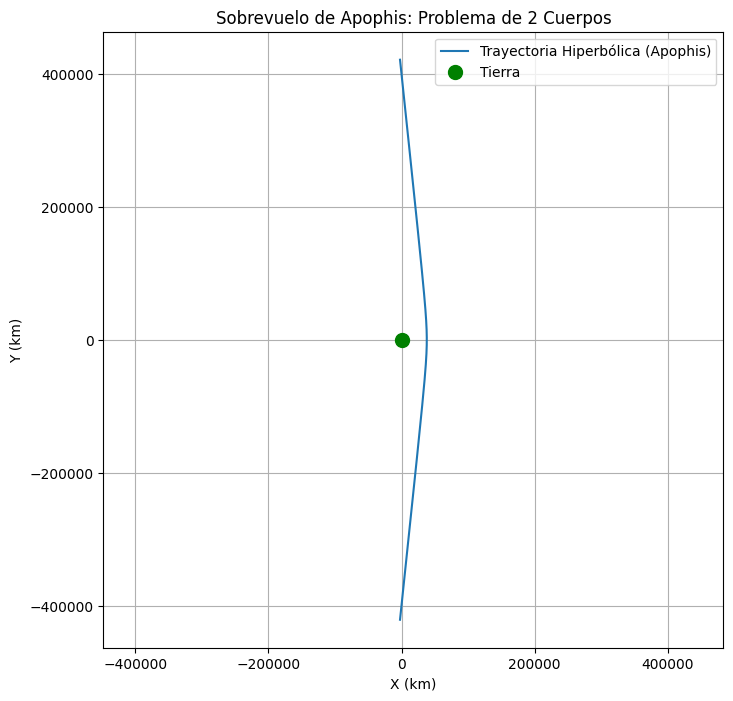

In [3]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros Físicos (SI)
G = 6.67430e-11
M_tierra = 5.9722e24
mu = G * M_tierra

# 2. Vectores de Estado en el Perigeo (obtenidos de tu certeza con Rebound)
rp_val = 38011000.0  # metros (38,011 km)
# Velocidad en perigeo para una hipérbola visible (aprox 10.5 km/s)
vp_val = 10500.0     

# Definimos vectores en el plano XY
r_vec = np.array([rp_val, 0, 0])
v_vec = np.array([0, vp_val, 0])

# 3. Cálculo de Elementos Orbitales (Problema de 2 Cuerpos)
v_mag = np.linalg.norm(v_vec)
r_mag = np.linalg.norm(r_vec)

# Energía específica
epsilon = (v_mag**2 / 2) - (mu / r_mag)

# Semieje mayor (negativo para hipérbola)
a = -mu / (2 * epsilon)

# Excentricidad
# rp = a(1 - e) -> e = 1 - (rp/a)
e = 1 - (r_mag / a)

# Momento angular
h_vec = np.cross(r_vec, v_vec)
h_mag = np.linalg.norm(h_vec)

print(f"--- Elementos Orbitales Calculados ---")
print(f"Semieje mayor (a): {a/1000:.2f} km")
print(f"Excentricidad (e): {e:.4f} (Hipérbola)")
print(f"Energía específica: {epsilon:.2e} J/kg")

# 4. Generación de la Trayectoria Analítica
# Usamos la ecuación de la cónica: r = p / (1 + e*cos(theta))
p = h_mag**2 / mu
theta = np.linspace(-np.arccos(-1/e)+0.1, np.arccos(-1/e)-0.1, 1000)
r_orbit = p / (1 + e * np.cos(theta))

x_orbit = r_orbit * np.cos(theta)
y_orbit = r_orbit * np.sin(theta)

# 5. Visualización
plt.figure(figsize=(8, 8))
plt.plot(x_orbit/1000, y_orbit/1000, label='Trayectoria Hiperbólica (Apophis)')
plt.plot(0, 0, 'go', ms=10, label='Tierra')
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.title("Sobrevuelo de Apophis: Problema de 2 Cuerpos")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML

# 1. Parámetros derivados de tus resultados previos
e = 9.5135        # Excentricidad calculada
rp = 38011.0      # Perigeo en km
mu = 398600.44    # GM de la Tierra en km^3/s^2
p = rp * (1 + e)  # Parámetro de la cónica

# 2. Definición de la trayectoria
# Ángulo de las asíntotas para una hipérbola
theta_max = np.arccos(-1/e) - 0.05 
theta = np.linspace(-theta_max, theta_max, 300)

# Ecuación de la cónica
r_orbit = p / (1 + e * np.cos(theta))
x_orbit = r_orbit * np.cos(theta)
y_orbit = r_orbit * np.sin(theta)

# 3. Creación de la Animación
fig, ax = plt.subplots(figsize=(7, 7))
camera = Camera(fig)

# Configuración estética del gráfico
ax.set_facecolor('#000000')  # Fondo negro como el espacio
ax.set_aspect('equal')
ax.grid(color='gray', linestyle='--', alpha=0.3)
ax.set_title("Simulación: Sobrevuelo de Apophis 2029", color='white')
ax.set_xlabel("Distancia X (km)", color='white')
ax.set_ylabel("Distancia Y (km)", color='white')

# Reducción de puntos para la animación (cada 5 pasos)
for i in range(0, len(theta), 5):
    # Dibujar la Tierra (punto fijo)
    ax.plot(0, 0, 'go', ms=12, label='Tierra' if i == 0 else "")
    
    # Dibujar la estela de la trayectoria ya recorrida
    ax.plot(x_orbit[:i], y_orbit[:i], color='cyan', lw=1, alpha=0.6)
    
    # Dibujar la posición actual de Apophis
    ax.plot(x_orbit[i], y_orbit[i], 'yo', ms=6, label='Apophis' if i == 0 else "")
    
    # Anotación de distancia dinámica
    dist_actual = np.sqrt(x_orbit[i]**2 + y_orbit[i]**2)
    ax.text(100000, 350000, f"Distancia: {dist_actual:,.0f} km", 
            color='white', fontsize=10, weight='bold')
    
    camera.snap()

# Generación del HTML
anim = camera.animate(interval=50, blit=True)
plt.close(fig)

# Mostrar animación en el cuaderno
HTML(anim.to_jshtml())